# In Class Assignment 7 — Classifying Penguins with Keras

Steps:

1. Load the palmerpenguins dataset and drop rows with missing values.
2. Build the feature matrix from the four numeric measurements plus one-hot encoded sex, then scale to [0, 1].
3. Encode the species column as integer class labels.
4. Split into train and test sets, stratified by species.
5. Define a dense feed-forward network with a softmax output over the three species.
6. Compile with sparse categorical cross-entropy (`from_logits=False`), train, and plot the loss/accuracy curves.
7. Predict on the test set and report accuracy, precision, recall, F1, ROC AUC, the confusion matrix, and a classification report.
8. Repeat with a logits-output model (no final activation, `from_logits=True`) to compare the two parameterisations of the same loss.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

tf.keras.utils.set_random_seed(42)
print('tensorflow', tf.__version__, '| keras', keras.__version__)

tensorflow 2.19.1 | keras 3.14.1


In [29]:
from palmerpenguins import load_penguins

penguins = load_penguins().dropna().reset_index(drop=True)
print('rows after dropna:', len(penguins))
penguins.head()

rows after dropna: 333


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [30]:
numeric_cols = ['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
sex_dummies = pd.get_dummies(penguins['sex'], dtype=float)

penguins_x = pd.concat([penguins[numeric_cols], sex_dummies], axis=1)
penguins_x.head()

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,3750.0,39.1,18.7,181.0,0.0,1.0
1,3800.0,39.5,17.4,186.0,1.0,0.0
2,3250.0,40.3,18.0,195.0,1.0,0.0
3,3450.0,36.7,19.3,193.0,1.0,0.0
4,3650.0,39.3,20.6,190.0,0.0,1.0


In [31]:
scaler = MinMaxScaler()
scaled_penguins_x = pd.DataFrame(
    scaler.fit_transform(penguins_x.values),
    columns=penguins_x.columns,
)
scaled_penguins_x.head()

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,0.291667,0.254545,0.666667,0.152542,0.0,1.0
1,0.305556,0.269091,0.511905,0.237288,1.0,0.0
2,0.152778,0.298182,0.583333,0.389831,1.0,0.0
3,0.208333,0.167273,0.738095,0.355932,1.0,0.0
4,0.263889,0.261818,0.892857,0.305085,0.0,1.0


In [32]:
species_cat = penguins['species'].astype('category')
class_names = list(species_cat.cat.categories)
penguins_y = species_cat.cat.codes.to_numpy()

print('classes:', class_names)
print('class counts:', np.bincount(penguins_y))

classes: ['Adelie', 'Chinstrap', 'Gentoo']
class counts: [146  68 119]


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_penguins_x.values,
    penguins_y,
    test_size=0.2,
    stratify=penguins_y,
    random_state=42,
)
print('train:', X_train.shape, '| test:', X_test.shape)

train: (266, 6) | test: (67, 6)


In [34]:
def build_model(name='penguin_model'):
    inputs = keras.Input(shape=(X_train.shape[1],))
    x = layers.Dense(7, activation='relu')(inputs)
    x = layers.Dense(5, activation='relu')(x)
    x = layers.Dense(3, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return keras.Model(inputs=inputs, outputs=outputs, name=name)

model = build_model()
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy'],
)

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.1,
    verbose=0,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'test loss: {test_loss:.4f} | test accuracy: {test_acc:.4f}')

test loss: 0.7027 | test accuracy: 0.7910


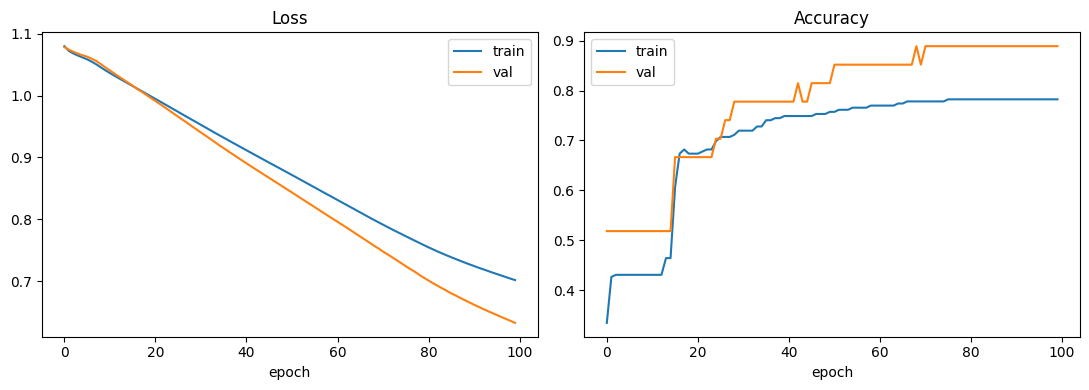

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [37]:
y_proba = model.predict(X_test, verbose=0)
y_pred = y_proba.argmax(axis=1)

print('Predictions are finite:', np.isfinite(y_proba).all())
print(f'accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'precision: {precision_score(y_test, y_pred, average="macro"):.4f}')
print(f'recall   : {recall_score(y_test, y_pred, average="macro"):.4f}')
print(f'f1       : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'roc auc  : {roc_auc_score(y_test, y_proba, multi_class="ovr"):.4f}')
print()
print('confusion matrix (rows = true, cols = pred):')
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=class_names, columns=class_names))
print()
print(classification_report(y_test, y_pred, target_names=class_names))

Predictions are finite: True
accuracy : 0.7910
precision: 0.5581
recall   : 0.6667
f1       : 0.6019
roc auc  : 0.8632

confusion matrix (rows = true, cols = pred):
           Adelie  Chinstrap  Gentoo
Adelie         29          0       0
Chinstrap      14          0       0
Gentoo          0          0      24

              precision    recall  f1-score   support

      Adelie       0.67      1.00      0.81        29
   Chinstrap       0.00      0.00      0.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.79        67
   macro avg       0.56      0.67      0.60        67
weighted avg       0.65      0.79      0.71        67



/Users/sahilbains/Downloads/AdvML/.venv-tf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sahilbains/Downloads/AdvML/.venv-tf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sahilbains/Downloads/AdvML/.venv-tf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## Logits-output variant

The same network, but the final dense layer has no activation so the model outputs raw logits. The loss is configured with `from_logits=True`, which applies softmax internally before computing cross-entropy. Predictions are converted to probabilities with `tf.nn.softmax` for evaluation.

In [38]:
def build_logits_model(name='penguin_model_logits'):
    inputs = keras.Input(shape=(X_train.shape[1],))
    x = layers.Dense(7, activation='relu')(inputs)
    x = layers.Dense(5, activation='relu')(x)
    x = layers.Dense(3, activation='relu')(x)
    outputs = layers.Dense(3)(x)
    return keras.Model(inputs=inputs, outputs=outputs, name=name)

model_logits = build_logits_model()
model_logits.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy'],
)

history_logits = model_logits.fit(
    X_train, y_train,
    batch_size=64, epochs=100, validation_split=0.1, verbose=0,
)

logits = model_logits.predict(X_test, verbose=0)
y_proba_logits = tf.nn.softmax(logits).numpy()
y_pred_logits = y_proba_logits.argmax(axis=1)

print(f'logits-model test accuracy: {accuracy_score(y_test, y_pred_logits):.4f}')
print(f'logits-model roc auc      : {roc_auc_score(y_test, y_proba_logits, multi_class="ovr"):.4f}')

logits-model test accuracy: 0.9254
logits-model roc auc      : 0.9961
